In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(14.4,7.4)

# The 2 cells below used to put the data sets ( experimental )

In [ ]:
# reading the oslo data for 300 bin (6,9)

df=pd.read_csv("../../input_data/gsf_97Zr.csv")

# convert to python arrays
energy1=df["energy"].values # as numpy array
gsf1=df["gsf"].values 
error1=df["errors"].values

In [4]:
df2=pd.read_csv("../../input_data/gsf_98_Zr_full.csv")

# convert to python arrays
energy2=df2["energy"].values # as numpy array
gsf2=df2["gsf"].values 
error2=df2["errors"].values


## plot the data sets

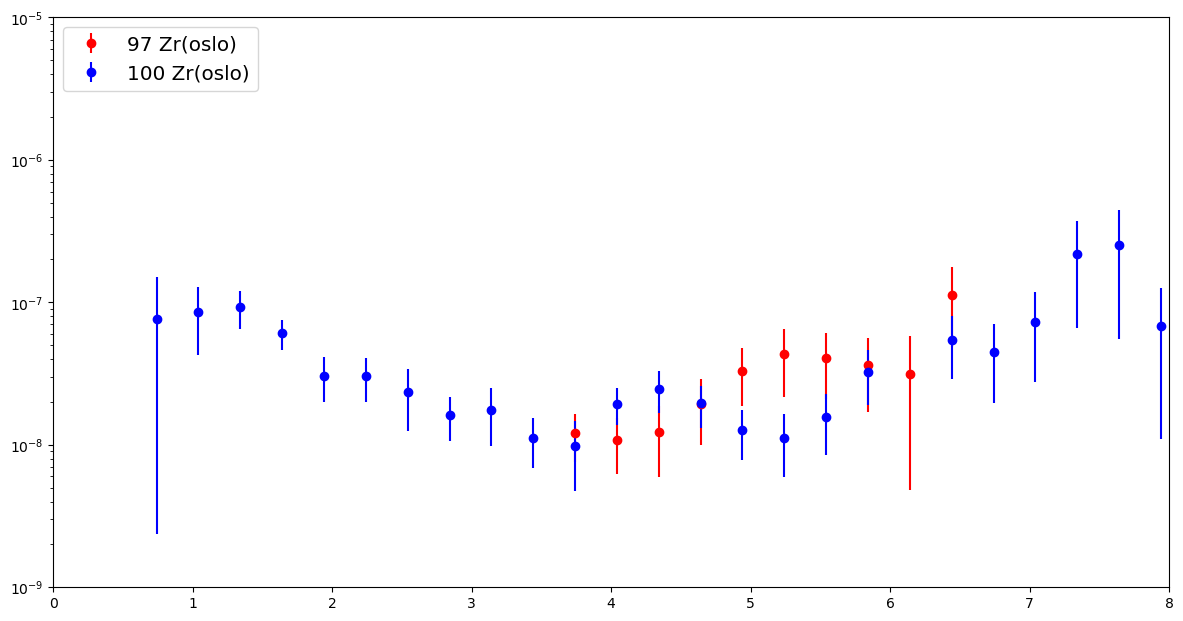

array([7.7016992e-08, 8.5883485e-08, 9.2218222e-08, 6.0686929e-08,
       3.0543355e-08, 3.0286845e-08, 2.3377565e-08, 1.6181250e-08,
       1.7457975e-08, 1.1152202e-08, 9.7666675e-09, 1.9412196e-08,
       2.4727814e-08, 1.9621281e-08, 1.2637337e-08, 1.1244668e-08,
       1.5592594e-08, 3.2652302e-08, 5.4525099e-08, 4.4954803e-08,
       7.2721633e-08, 2.2019076e-07, 2.5168987e-07, 6.8155764e-08])

In [5]:

fig = plt.figure()

plt.errorbar(energy1, gsf1,yerr=error1,fmt="o", color="r",ecolor='r',label='97 Zr(oslo)')
plt.errorbar(energy2, gsf2,yerr=error2,fmt="o", color="b",ecolor='b',label='100 Zr(oslo)')


plt.yscale("log")

plt.xlim(0, 8)
plt.ylim(10**(-9),10**(-5))

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()

gsf2

## the talys file which has the input values (upbende, upbendc,ftable) is called the optimal_gsf 1.txt..... you can choose this

In [ ]:
df3=pd.read_table("optimal_gsf 1.txt",delimiter="\s+",skiprows=2,header=None)

df3.columns=['energy','f(M1)','f(E1)','T(M1)','T(E1)']
df3['gsf'] = df3['f(M1)'] + df3['f(E1)']



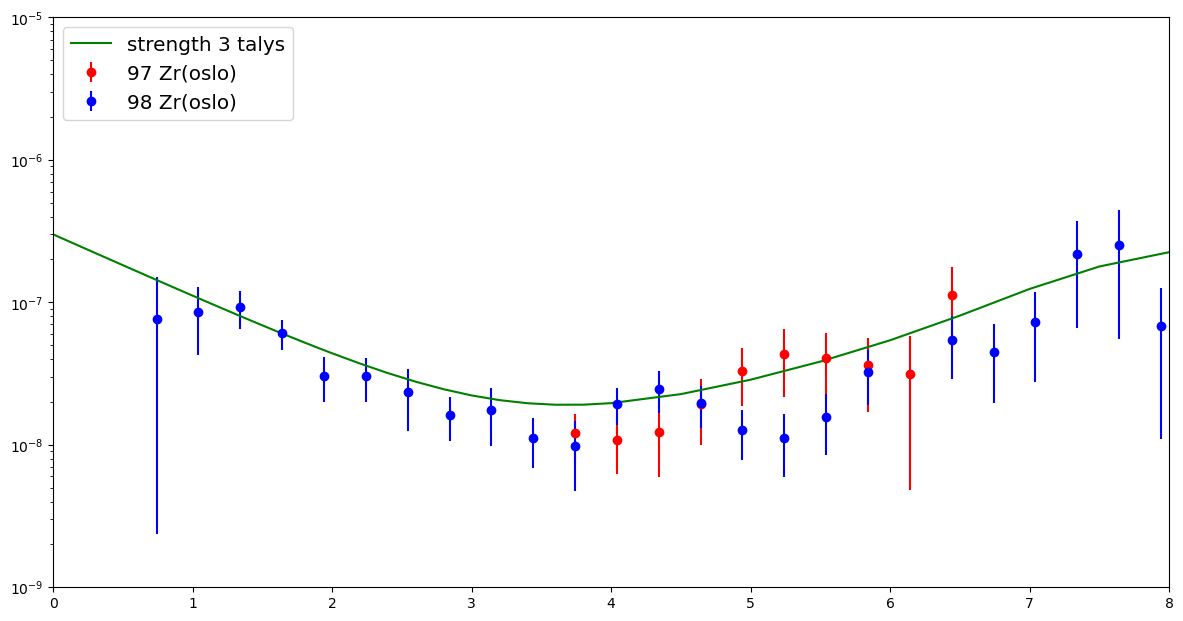

,energy,f(M1),f(E1),T(M1),T(E1),gsf
0,0.001,2.997000e-07,0.000000e+00,1.883070e-15,0.000000e+00,2.997000e-07
1,0.002,2.994020e-07,0.000000e+00,1.504960e-14,0.000000e+00,2.994020e-07
2,0.005,2.985060e-07,0.000000e+00,2.344460e-13,0.000000e+00,2.985060e-07
3,0.010,2.970200e-07,0.000000e+00,1.866230e-12,0.000000e+00,2.970200e-07
4,0.020,2.940700e-07,0.000000e+00,1.478160e-11,0.000000e+00,2.940700e-07
5,0.050,2.853950e-07,0.000000e+00,2.241490e-10,0.000000e+00,2.853950e-07
6,0.100,2.715040e-07,0.000000e+00,1.705910e-09,0.000000e+00,2.715040e-07
7,0.200,2.457250e-07,2.006240e-11,1.235150e-08,1.008450e-12,2.457451e-07
8,0.300,2.224040e-07,4.518130e-11,3.772990e-08,7.664830e-12,2.224492e-07
9,0.400,2.013070e-07,8.041430e-11,8.095040e-08,3.233650e-11,2.013874e-07


In [ ]:
# plotting the talys here along with dat sets

fig = plt.figure()

plt.errorbar(energy1, gsf1,yerr=error1,fmt="o", color="r",ecolor='r',label='97 Zr(oslo)')
plt.errorbar(energy2, gsf2,yerr=error2,fmt="o", color="b",ecolor='b',label='98 Zr(oslo)')

plt.plot(df3['energy'],df3['gsf'],color ='green', label ='strength 3 talys')

plt.yscale("log")

plt.xlim(0, 8)
plt.ylim(10**(-9),10**(-5))

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()

df3.head(10)

## the talys file which has the input values (upbende, upbendc,ftable) in default_mode(base values) is called the base_strength.txt

In [ ]:
df_construct=pd.read_table("base_strength.txt",delimiter="\s+",skiprows=2,header=None)

df_construct.columns=['energy','f(M1)','f(E1)','T(M1)','T(E1)']

df_construct['gsf'] = df_construct['f(E1)']+ df_construct['f(M1)']

df_construct.to_pickle("master_base_gsf.pkl")



# constructing the GSF from the values chosen
# f(E1)
ftable=1
C= 0
U =  6.827386
eta =3

#f(M1)
upbende =1
upbendc = 3*10**(-7)

# note that above values must match the talys input file in optimal_gsf 1.txt.


# f(e1) construction
df_construct['f(E1)']= ftable * df_construct['f(E1)']+  (C* (U-df_construct['energy']))/(1+np.exp(df_construct['energy']-eta))

#f(m1) construction
df_construct['f(M1)']=  df_construct['f(M1)']+  upbendc * np.exp(-1*upbende*df_construct['energy'])

df_construct['gsf'] = df_construct['f(E1)']+ df_construct['f(M1)']


df_construct.head(30)


,energy,f(M1),f(E1),T(M1),T(E1),gsf
0,0.001,2.997001e-07,0.000000e+00,0.000000e+00,0.000000e+00,2.997001e-07
1,0.002,2.994017e-07,0.000000e+00,5.286840e-20,0.000000e+00,2.994017e-07
2,0.005,2.985064e-07,0.000000e+00,2.065170e-18,0.000000e+00,2.985064e-07
3,0.010,2.970202e-07,0.000000e+00,3.304280e-17,0.000000e+00,2.970202e-07
4,0.020,2.940701e-07,0.000000e+00,5.286880e-16,0.000000e+00,2.940701e-07
5,0.050,2.853951e-07,0.000000e+00,2.065290e-14,0.000000e+00,2.853951e-07
6,0.100,2.715038e-07,0.000000e+00,3.305020e-13,0.000000e+00,2.715038e-07
7,0.200,2.457245e-07,2.006240e-11,5.291640e-12,1.008450e-12,2.457446e-07
8,0.300,2.224036e-07,4.518130e-11,2.681940e-11,7.664830e-12,2.224487e-07
9,0.400,2.013071e-07,8.041430e-11,8.489770e-11,3.233650e-11,2.013876e-07


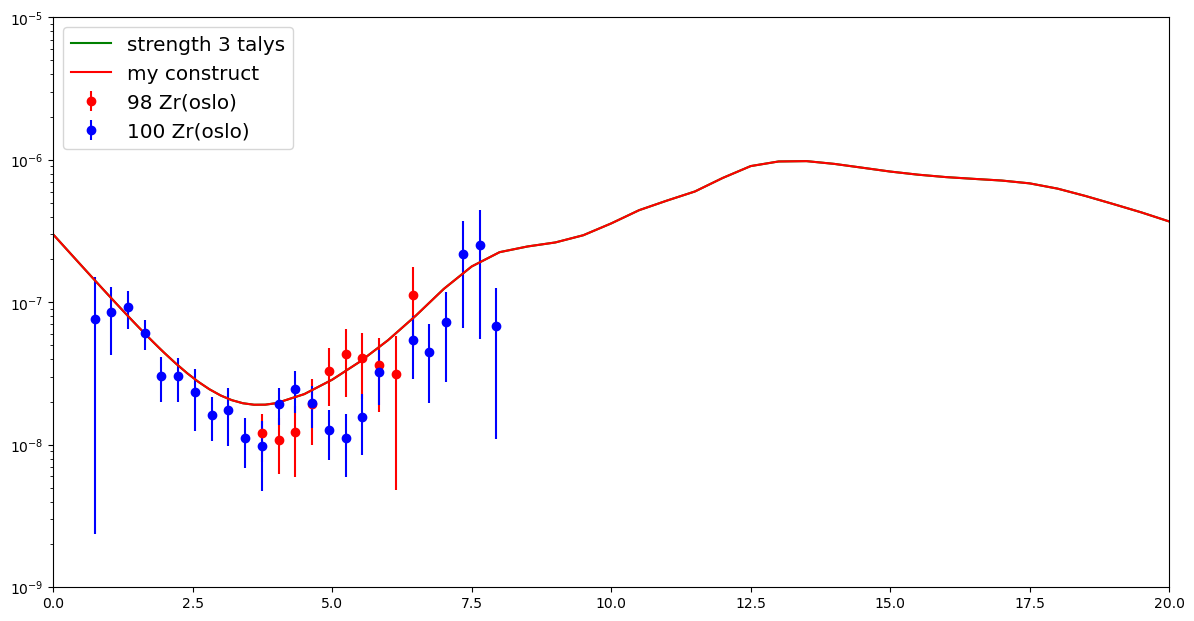

In [ ]:
# drawing the constructed vs optimal and see they overlapp or not



fig = plt.figure()
 
plt.errorbar(energy1, gsf1,yerr=error1,fmt="o", color="r",ecolor='r',label='98 Zr(oslo)')
plt.errorbar(energy2, gsf2,yerr=error2,fmt="o", color="b",ecolor='b',label='100 Zr(oslo)')

plt.plot(df3['energy'],df3['gsf'],color ='green', label ='strength 3 talys')

plt.plot(df_construct['energy'],df_construct['gsf'],color ='red', label ='my construct')

plt.yscale("log")

plt.xlim(0, 20)
plt.ylim(10**(-9),10**(-5))

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()

